# Multi-Hop Factual Reasoning Task Family Dataset (1–6 Hops)

This notebook demonstrates the **Multi-Hop Factual Reasoning Dataset**, which contains 180 questions
spanning 6 difficulty levels (30 per hop count 1–6).

- **Hops 1–4**: Sourced from MuSiQue (answerable) with 1-hop extracted from sub-question decompositions. Hop 2 supplemented with 10 HotpotQA bridge questions.
- **Hops 5–6**: Synthetic, composed via LLM from entity-chained MuSiQue sub-questions.

Each example has an input (question), output (short factual answer), and metadata including difficulty level, source provenance, answer aliases, and the full supporting-facts reasoning chain.

The code below loads a curated mini subset, validates it, computes summary statistics, and visualises the dataset structure.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import random
import sys
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Load the curated mini demo dataset. Tries GitHub URL first (for Colab), falls back to local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/dataset_iter1_multi_hop_factu/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded dataset: {data['metadata']['description']}")
print(f"Total examples: {data['metadata']['total_examples']}")
print(f"Hop levels: {data['metadata']['hop_levels']}")
print(f"Sources: {data['metadata']['sources']}")

Loaded dataset: Multi-Hop Factual Reasoning Task Family Dataset (1-6 Hops)
Total examples: 18
Hop levels: 1-6
Sources: ['musique_decomposition', 'musique', 'hotpotqa', 'synthetic']


## Configuration

Tunable parameters for analysis. Using the full mini demo dataset.

In [5]:
# --- Config ---
SEED = 42
random.seed(SEED)

# Number of examples to process (use all available in mini dataset)
N_SAMPLES = len(data['datasets'][0]['examples'])  # 18 in mini demo
# Original full dataset: TARGET_PER_HOP = 30, total = 180

examples = data['datasets'][0]['examples'][:N_SAMPLES]
print(f"Processing {len(examples)} examples")

Processing 18 examples


## Helper Functions

Utility functions from the original dataset builder for answer validation and formatting.

In [6]:
def is_short_answer(answer: str) -> bool:
    """True if answer is a short factual entity (≤5 words, <100 chars)."""
    return 0 < len(answer) < 100 and len(answer.split()) <= 5


def validate_dataset_group(name: str, examples: list) -> list:
    """Validate a single dataset group. Returns list of error messages."""
    errors = []
    ids_seen = set()
    hop_counts = defaultdict(int)

    for i, ex in enumerate(examples):
        if "input" not in ex:
            errors.append(f"[{name}] example {i}: missing 'input'")
        if "output" not in ex:
            errors.append(f"[{name}] example {i}: missing 'output'")
        if not ex.get("output"):
            errors.append(f"[{name}] example {i}: empty 'output'")
        if len(str(ex.get("output", ""))) > 100:
            errors.append(f"[{name}] example {i}: output >100 chars")

        eid = ex.get("metadata_id", "")
        if eid in ids_seen:
            errors.append(f"[{name}] example {i}: duplicate id '{eid}'")
        ids_seen.add(eid)

        dl = ex.get("metadata_difficulty_level")
        if isinstance(dl, int):
            hop_counts[dl] += 1
        else:
            errors.append(f"[{name}] example {i}: difficulty_level not int")

    return errors

## Dataset Validation

Run the original validation logic to ensure all examples conform to the schema.

In [7]:
logger.info("Validating dataset...")
all_errs = validate_dataset_group("multi_hop_reasoning_1to6", examples)
if all_errs:
    for e in all_errs:
        logger.error(e)
    logger.warning(f"Validation found {len(all_errs)} error(s)")
else:
    logger.info("Validation PASSED - all examples conform to schema")
    print("\nAll examples have: input, output, metadata_fold, metadata_difficulty_level,")
    print("metadata_source, metadata_id, metadata_task_type, metadata_answer_aliases,")
    print("metadata_supporting_facts")

08:52:49|INFO   |Validating dataset...


08:52:49|INFO   |Validation PASSED - all examples conform to schema



All examples have: input, output, metadata_fold, metadata_difficulty_level,
metadata_source, metadata_id, metadata_task_type, metadata_answer_aliases,
metadata_supporting_facts


## Dataset Statistics & Summary

Compute distribution statistics across hop levels and data sources.

In [8]:
# Build summary statistics
hop_counts = defaultdict(int)
src_counts = defaultdict(int)
answer_lengths = []
question_lengths = []

for ex in examples:
    hop_counts[ex['metadata_difficulty_level']] += 1
    src_counts[ex['metadata_source']] += 1
    answer_lengths.append(len(ex['output'].split()))
    question_lengths.append(len(ex['input'].split()))

print("=" * 60)
print("DATASET: multi_hop_reasoning_1to6 (hops 1-6, combined)")
print(f"Total examples: {len(examples)}")
print()
print("Distribution by hop level:")
for lvl in sorted(hop_counts):
    print(f"  Level {lvl} ({lvl}-hop): {hop_counts[lvl]} examples")
print()
print("Distribution by source:")
for src, cnt in sorted(src_counts.items()):
    print(f"  {src}: {cnt}")
print()
print(f"Answer length: {np.mean(answer_lengths):.1f} words avg (range: {min(answer_lengths)}-{max(answer_lengths)})")
print(f"Question length: {np.mean(question_lengths):.1f} words avg (range: {min(question_lengths)}-{max(question_lengths)})")

DATASET: multi_hop_reasoning_1to6 (hops 1-6, combined)
Total examples: 18

Distribution by hop level:
  Level 1 (1-hop): 3 examples
  Level 2 (2-hop): 3 examples
  Level 3 (3-hop): 3 examples
  Level 4 (4-hop): 3 examples
  Level 5 (5-hop): 3 examples
  Level 6 (6-hop): 3 examples

Distribution by source:
  hotpotqa: 1
  musique: 8
  musique_decomposition: 3
  synthetic: 6

Answer length: 1.8 words avg (range: 1-4)
Question length: 23.3 words avg (range: 3-44)


## Sample Questions by Hop Level

Display one sample question per difficulty level with its reasoning chain.

In [9]:
print("Sample questions by hop level:")
print("-" * 60)
for lvl in range(1, 7):
    lvl_qs = [e for e in examples if e['metadata_difficulty_level'] == lvl]
    if lvl_qs:
        ex = lvl_qs[0]
        print(f"\n[{lvl}-hop] Q: {ex['input'][:120]}")
        print(f"         A: {ex['output']}")
        print(f"         Source: {ex['metadata_source']}")
        # Show supporting facts chain
        sf = json.loads(ex['metadata_supporting_facts'])
        if sf:
            print(f"         Reasoning chain ({len(sf)} steps):")
            for step in sf:
                print(f"           Hop {step['hop']}: {step['question'][:80]} -> {step['answer']}")

Sample questions by hop level:
------------------------------------------------------------

[1-hop] Q: Yorke Bay >> country
         A: Falkland Islands
         Source: musique_decomposition
         Reasoning chain (1 steps):
           Hop 1: Yorke Bay >> country -> Falkland Islands

[2-hop] Q: Who is the child of the president under whom prohibition occurred?
         A: Jessie Woodrow Wilson
         Source: musique
         Reasoning chain (2 steps):
           Hop 1: who was president the prohibition of alcohol went into effect -> Woodrow Wilson
           Hop 2: #1 >> child -> Jessie Woodrow Wilson

[3-hop] Q: When did the location of the basilica that is named after the same saint as the San Pietro in Ciel d'Oro become its own 
         A: 11 February 1929
         Source: musique
         Reasoning chain (3 steps):
           Hop 1: San Pietro in Ciel d'Oro >> named after -> Peter
           Hop 2: st. #1 ’s basilica the head of the catholic religion is located in -> Vatican

## Visualization

Visualize the dataset structure: distribution by hop level and source, plus question/answer length patterns.

/tmp/ipykernel_202/55034787.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(bp_data, labels=[str(l) for l in levels], patch_artist=True)


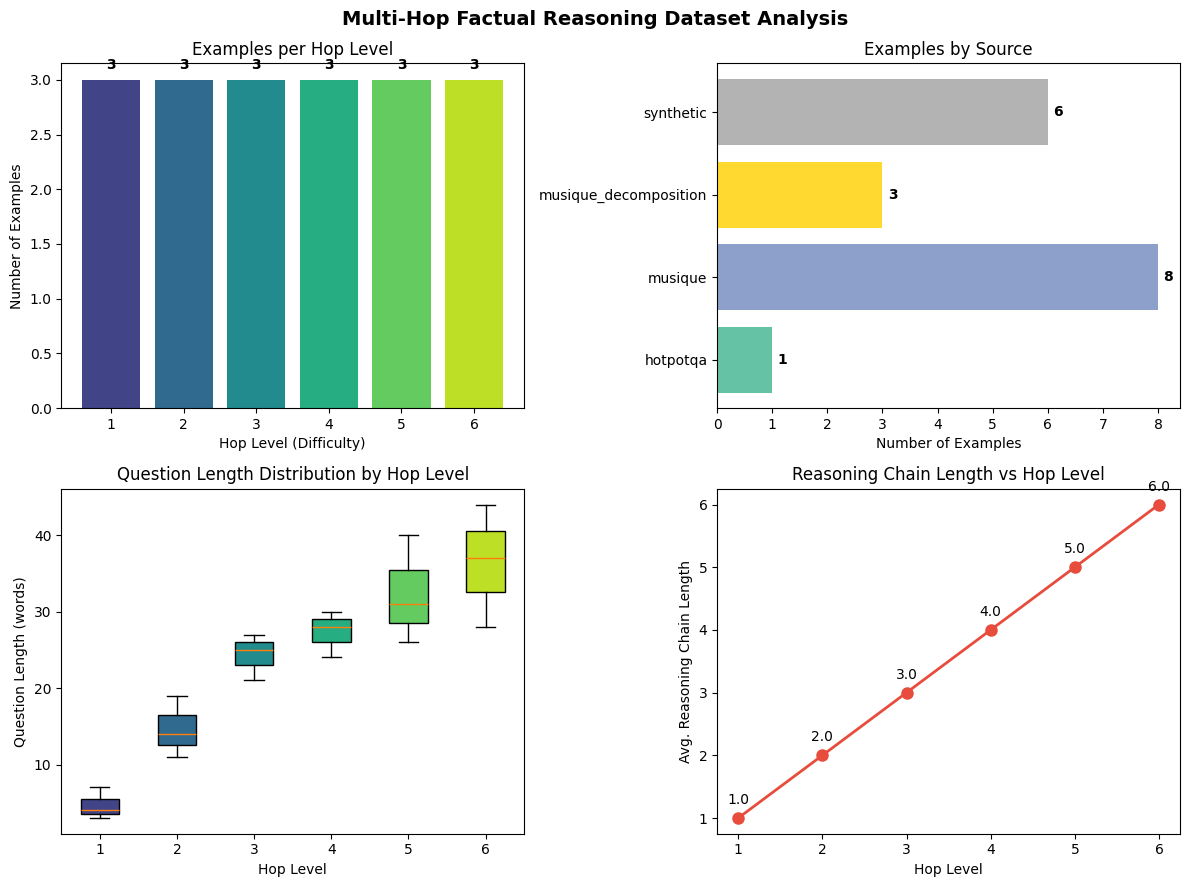


Dataset demo complete!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# --- Plot 1: Examples per hop level ---
levels = sorted(hop_counts.keys())
counts = [hop_counts[l] for l in levels]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(levels)))
axes[0, 0].bar([str(l) for l in levels], counts, color=colors)
axes[0, 0].set_xlabel('Hop Level (Difficulty)')
axes[0, 0].set_ylabel('Number of Examples')
axes[0, 0].set_title('Examples per Hop Level')
for i, (l, c) in enumerate(zip(levels, counts)):
    axes[0, 0].text(i, c + 0.1, str(c), ha='center', fontweight='bold')

# --- Plot 2: Examples by source ---
sources = sorted(src_counts.keys())
src_vals = [src_counts[s] for s in sources]
src_colors = plt.cm.Set2(np.linspace(0, 1, len(sources)))
axes[0, 1].barh(sources, src_vals, color=src_colors)
axes[0, 1].set_xlabel('Number of Examples')
axes[0, 1].set_title('Examples by Source')
for i, v in enumerate(src_vals):
    axes[0, 1].text(v + 0.1, i, str(v), va='center', fontweight='bold')

# --- Plot 3: Question length by hop level ---
q_len_by_hop = defaultdict(list)
for ex in examples:
    q_len_by_hop[ex['metadata_difficulty_level']].append(len(ex['input'].split()))
bp_data = [q_len_by_hop[l] for l in levels]
bp = axes[1, 0].boxplot(bp_data, labels=[str(l) for l in levels], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1, 0].set_xlabel('Hop Level')
axes[1, 0].set_ylabel('Question Length (words)')
axes[1, 0].set_title('Question Length Distribution by Hop Level')

# --- Plot 4: Supporting facts chain length ---
sf_len_by_hop = defaultdict(list)
for ex in examples:
    sf = json.loads(ex['metadata_supporting_facts'])
    sf_len_by_hop[ex['metadata_difficulty_level']].append(len(sf))
avg_sf = [np.mean(sf_len_by_hop[l]) for l in levels]
axes[1, 1].plot(levels, avg_sf, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Hop Level')
axes[1, 1].set_ylabel('Avg. Reasoning Chain Length')
axes[1, 1].set_title('Reasoning Chain Length vs Hop Level')
axes[1, 1].set_xticks(levels)
for l, v in zip(levels, avg_sf):
    axes[1, 1].annotate(f'{v:.1f}', (l, v), textcoords='offset points', xytext=(0, 10), ha='center')

plt.suptitle('Multi-Hop Factual Reasoning Dataset Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDataset demo complete!")